# 🏠 Zameen Islamabad — House Price Predictor

---

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, os, json, shutil, re
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import sys, subprocess, importlib
def ensure_packages(packages):
    for pkg in packages:
        try:
            importlib.import_module(pkg)
        except Exception:
            print(f'Installing {pkg}...')
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

# Ensure core ML libs are available (will install if missing)
ensure_packages(['xgboost','catboost','lightgbm'])
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb
import joblib

SCRIPT_DIR = os.path.abspath('')
DATA_PATH  = os.path.join(SCRIPT_DIR, '../data/zameen_islamabad.csv')
MODELS_DIR = os.path.join(SCRIPT_DIR, 'models')
APP_DIR    = os.path.join(SCRIPT_DIR, '../app')
CHARTS_DIR = os.path.join(APP_DIR, 'charts')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(CHARTS_DIR, exist_ok=True)
print('✅ Ready')

✅ Ready


## 📥 Step 1 — Load & Clean Data

In [44]:
def clean_price(val):
    if pd.isna(val): return np.nan
    val = str(val).lower().replace(',','').strip()
    try:
        num = float(val.split()[0])
        if 'lakh'  in val: return num * 1e5
        if 'crore' in val: return num * 1e7
        if 'arab'  in val: return num * 1e9
        return num
    except: return np.nan

def clean_area(val):
    if pd.isna(val): return np.nan
    val = str(val).lower().replace(',','').strip()
    try:
        num = float(val.split()[0])
        if 'kanal'   in val: return num * 20
        if 'sq. yd.' in val: return num / 25
        return num
    except: return np.nan

def extract_sector(loc):
    m = re.search(r'\b([A-Z]-\d{1,2})\b', str(loc))
    if m: return m.group(1)
    parts = str(loc).split(',')
    return parts[-1].strip() if len(parts) > 1 else str(loc).strip()

def area_category(a):
    if a <= 6:  return '5_marla'
    if a <= 12: return '10_marla'
    if a <= 22: return '1_kanal'
    if a <= 42: return '2_kanal'
    return 'estate'

def safe_col(n): return re.sub(r'[^A-Za-z0-9_]', '_', n)

def price_to_bin(p):
    if p < 8e6:  return 'Under 80L'
    if p < 3e7:  return '80L-3Cr'
    if p < 8e7:  return '3Cr-8Cr'
    return '8Cr+'

df = pd.read_csv(DATA_PATH)
print('Raw shape:', df.shape)
df['price'] = df['price'].apply(clean_price)
df['area']  = df['area'].apply(clean_area)
df = df.dropna(subset=['price','area'])
df.drop(columns=['url','city','drawing_rooms'], inplace=True, errors='ignore')

# Keep luxury properties — only remove data entry errors
df = df[(df['price'] >= 1_000_000) & (df['area'] >= 1) & (df['area'] <= 500)]

for col in ['bedrooms','bathrooms','parking','servant_quarters','store_rooms','kitchens','built_in_year']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.drop_duplicates()
df['sector']   = df['location'].apply(extract_sector)
df['area_cat'] = df['area'].apply(area_category)
df['ppm']      = df['price'] / df['area']
print(f'Clean shape: {df.shape} | Sectors: {df["sector"].nunique()} | Locations: {df["location"].nunique()}')

Raw shape: (3238, 14)
Clean shape: (3231, 14) | Sectors: 105 | Locations: 408


## 📍 Step 2 — Sector Pricing Intelligence Engine
> Builds dynamic PPM for every sector × area-size × property-type combination

In [45]:
AREA_CATS   = ['5_marla','10_marla','1_kanal','2_kanal','estate']
global_ppm  = df['ppm'].median()
global_mean = df['price'].mean()

# ── 2a: Sector-level PPM ──────────────────────────────────
sector_ppm_df  = df.groupby('sector')['ppm'].agg(['median','mean','std','count']).reset_index()
sector_ppm_df.columns = ['sector','median_ppm','mean_ppm','std_ppm','count']
sector_ppm_map = dict(zip(sector_ppm_df['sector'], sector_ppm_df['median_ppm']))

# ── 2b: Sector × Area-Category PPM ───────────────────────
sec_area = df.groupby(['sector','area_cat'])['ppm'].agg(['median','count']).reset_index()
sec_area.columns = ['sector','area_cat','ppm_median','count']
sector_area_ppm = {}
for _, row in sec_area.iterrows():
    s,ac,p,c = row['sector'],row['area_cat'],row['ppm_median'],row['count']
    if s not in sector_area_ppm: sector_area_ppm[s] = {}
    sector_area_ppm[s][ac] = {'ppm':float(p),'count':int(c),'reliable':c>=3}
for sec in sector_area_ppm:
    fb = sector_ppm_map.get(sec, global_ppm)
    for ac in AREA_CATS:
        if ac not in sector_area_ppm[sec]:
            sector_area_ppm[sec][ac] = {'ppm':float(fb),'count':0,'reliable':False}

# ── 2c: Sector × Property-Type PPM ───────────────────────
sec_type = df.groupby(['sector','property_type'])['ppm'].agg(['median','count']).reset_index()
sec_type.columns = ['sector','property_type','ppm_median','count']
sector_type_ppm = {}
for _, row in sec_type.iterrows():
    s,pt,p,c = row['sector'],row['property_type'],row['ppm_median'],row['count']
    if s not in sector_type_ppm: sector_type_ppm[s] = {}
    sector_type_ppm[s][pt] = {'ppm':float(p),'count':int(c)}

# ── 2d: 3-Way: Sector × Area × Property Type ─────────────
sec_area_type = df.groupby(['sector','area_cat','property_type'])['ppm'].agg(['median','count']).reset_index()
sec_area_type.columns = ['sector','area_cat','property_type','ppm_median','count']
sector_area_type_ppm = {}
for _, row in sec_area_type.iterrows():
    s,ac,pt,p,c = row['sector'],row['area_cat'],row['property_type'],row['ppm_median'],row['count']
    if s not in sector_area_type_ppm: sector_area_type_ppm[s] = {}
    if ac not in sector_area_type_ppm[s]: sector_area_type_ppm[s][ac] = {}
    sector_area_type_ppm[s][ac][pt] = {'ppm':float(p),'count':int(c),'reliable':c>=3}

# ── 2e: Luxury sector map ─────────────────────────────────
lux_thresh       = df['ppm'].quantile(0.75)
luxury_sector_map = {s:float(sector_ppm_map[s]/global_ppm)
                     for s in sector_ppm_map if sector_ppm_map[s]>=lux_thresh}

# ── 2f: Area-size multipliers ─────────────────────────────
area_multipliers = {ac:float(df[df['area_cat']==ac]['ppm'].median()/global_ppm)
                    for ac in AREA_CATS}

# ── 2g: Per-sector area scaling ───────────────────────────
premium_area_multipliers = {}
for sec in sector_area_ppm:
    base = sector_ppm_map.get(sec, global_ppm)
    if base == 0: continue
    premium_area_multipliers[sec] = {ac:float(sector_area_ppm[sec][ac]['ppm']/base) for ac in AREA_CATS}

print(f'sector_ppm_map          : {len(sector_ppm_map)} sectors')
print(f'sector_area_ppm         : {len(sector_area_ppm)} × 5 area categories')
print(f'sector_area_type_ppm    : 3-way lookup')
print(f'luxury_sector_map       : {len(luxury_sector_map)} luxury sectors')
print(f'area_multipliers        : {area_multipliers}')
print(f'Luxury sectors          : {list(luxury_sector_map.keys())}')

sector_ppm_map          : 105 sectors
sector_area_ppm         : 105 × 5 area categories
sector_area_type_ppm    : 3-way lookup
luxury_sector_map       : 17 luxury sectors
area_multipliers        : {'5_marla': 0.9439102564102565, '10_marla': 0.9317307692307693, '1_kanal': 1.1783653846153848, '2_kanal': 1.5985576923076923, 'estate': 1.5224358974358974}
Luxury sectors          : ['Blue Area', 'D-12', 'E-7', 'F-10', 'F-11', 'F-6', 'F-7', 'F-8', 'G-10', 'G-11', 'G-13', 'G-6', 'G-7', 'G-8', 'G-9', 'I-8', 'Margalla Town']


In [46]:
# ── Dynamic PPM lookup function ───────────────────────────
def get_dynamic_ppm(sector, area, property_type='House'):
    """
    4-level cascading lookup:
    L1: sector × area_cat × property_type  (most specific)
    L2: sector × area_cat + type blending
    L3: sector + global area multiplier
    L4: global fallback
    """
    ac = area_category(area)

    # L1: 3-way
    if (sector in sector_area_type_ppm and
        ac in sector_area_type_ppm[sector] and
        property_type in sector_area_type_ppm[sector][ac] and
        sector_area_type_ppm[sector][ac][property_type]['reliable']):
        return float(sector_area_type_ppm[sector][ac][property_type]['ppm']), 'L1'

    # L2: sector × area
    if sector in sector_area_ppm and sector_area_ppm[sector].get(ac,{}).get('reliable'):
        ppm = sector_area_ppm[sector][ac]['ppm']
        if sector in sector_type_ppm and property_type in sector_type_ppm[sector]:
            type_ppm  = sector_type_ppm[sector][property_type]['ppm']
            sec_base  = sector_ppm_map.get(sector, global_ppm)
            type_mult = np.clip(type_ppm / max(sec_base,1), 0.6, 1.8)
            ppm = ppm * (0.75 + 0.25*type_mult)
        return float(ppm), 'L2'

    # L3: sector + area multiplier
    if sector in sector_ppm_map:
        return float(sector_ppm_map[sector] * area_multipliers.get(ac,1.0)), 'L3'

    # L4: global
    return float(global_ppm * area_multipliers.get(ac,1.0)), 'L4'

def compute_baseline(sector, area, property_type='House'):
    ppm, method = get_dynamic_ppm(sector, area, property_type)
    return float(ppm*area), float(ppm), method

# ── Validation ────────────────────────────────────────────
print('=== PRICING ENGINE VALIDATION ===')
print(f"{'Sector':<16} {'Area':>5} {'Type':<12} {'PPM (L/M)':>10} {'Total':>10} Method")
print('-'*65)
for s,a,pt in [
    ('F-6',5,'House'), ('F-6',20,'House'), ('F-6',50,'House'),
    ('DHA Defence',5,'House'), ('DHA Defence',20,'House'), ('DHA Defence',40,'House'),
    ('B-17',5,'House'), ('B-17',10,'House'),
    ('G-11',5,'Flat'), ('G-13',10,'House'),
]:
    bl,ppm,m = compute_baseline(s,a,pt)
    print(f'{s:<16} {a:>5}M {pt:<12} {ppm/1e5:>9.1f}L {bl/1e7:>9.1f}Cr {m}')

=== PRICING ENGINE VALIDATION ===
Sector            Area Type          PPM (L/M)      Total Method
-----------------------------------------------------------------
F-6                  5M House            141.1L       7.1Cr L3
F-6                 20M House            132.7L      26.5Cr L1
F-6                 50M House            159.4L      79.7Cr L1
DHA Defence          5M House             70.0L       3.5Cr L1
DHA Defence         20M House             56.9L      11.4Cr L1
DHA Defence         40M House             52.5L      21.0Cr L1
B-17                 5M House             50.0L       2.5Cr L1
B-17                10M House             50.0L       5.0Cr L1
G-11                 5M Flat              98.0L       4.9Cr L2
G-13                10M House             82.5L       8.2Cr L1


## 🔧 Step 3 — Feature Engineering (with Pricing Intelligence)

In [47]:
# Location encoding
loc_stats = df.groupby('location')['price'].agg(['mean','median','count']).reset_index()
loc_stats.columns = ['location','mean_price','median_price','listing_count']
loc_stats['sector'] = loc_stats['location'].apply(extract_sector)
sec_mean_df = df.groupby('sector')['price'].agg(['mean','median','count']).reset_index()
sec_mean_df.columns = ['sector','sector_mean','sector_median','sector_count']
loc_stats = loc_stats.merge(sec_mean_df[['sector','sector_mean']], on='sector', how='left')
loc_stats['smoothed_mean'] = loc_stats.apply(
    lambda r: r['mean_price'] if r['listing_count']>=5 else r.get('sector_mean', global_mean), axis=1)
loc_mean_map    = dict(zip(loc_stats['location'], loc_stats['smoothed_mean']))
sector_mean_map = dict(zip(sec_mean_df['sector'], sec_mean_df['sector_mean']))
loc_stats_dict  = loc_stats.set_index('location')[['mean_price','median_price','listing_count','smoothed_mean']].to_dict(orient='index')

le = LabelEncoder()
df['property_type_enc'] = le.fit_transform(df['property_type'].astype(str))
sparse_cols = ['bedrooms','bathrooms','parking','servant_quarters','store_rooms','kitchens']
imputer = KNNImputer(n_neighbors=5)
df[sparse_cols] = imputer.fit_transform(df[sparse_cols])

df['property_age'] = (2025 - df['built_in_year']).clip(0,50).fillna(10)
df['is_new']       = (df['property_age'] <= 1).astype(int)
df['location_enc'] = df['location'].map(loc_mean_map).fillna(global_mean)
df['sector_enc']   = df['sector'].map(sector_mean_map).fillna(global_mean)

# ── Pricing intelligence features ──────────────────────────
print('Computing dynamic pricing features...')
bl_list, ppm_list = [], []
for _, row in df.iterrows():
    bl, ppm, _ = compute_baseline(row['sector'], row['area'], row['property_type'])
    bl_list.append(bl); ppm_list.append(ppm)

df['baseline_price']       = bl_list
df['dynamic_ppm']          = ppm_list
df['log_baseline']         = np.log1p(df['baseline_price'])
df['log_dynamic_ppm']      = np.log1p(df['dynamic_ppm'])
df['is_luxury_sector']     = df['sector'].isin(luxury_sector_map.keys()).astype(int)
df['sector_ppm_enc']       = df['sector'].map(sector_ppm_map).fillna(global_ppm)
df['area_cat_enc']         = df['area_cat'].map({'5_marla':0,'10_marla':1,'1_kanal':2,'2_kanal':3,'estate':4})
df['luxury_premium']       = df['sector'].map(luxury_sector_map).fillna(1.0)
df['ppm_x_area']           = df['dynamic_ppm'] * df['area']
df['baseline_x_beds']      = df['log_baseline'] * df['bedrooms']
df['ppm_x_beds']           = df['dynamic_ppm'] * df['bedrooms']

# Standard features
df['log_area']           = np.log1p(df['area'])
df['log_beds']           = np.log1p(df['bedrooms'])
df['log_baths']          = np.log1p(df['bathrooms'])
df['log_loc_price']      = np.log1p(df['location_enc'])
df['log_sector_price']   = np.log1p(df['sector_enc'])
df['area_sq']            = df['area']**2
df['log_area_sq']        = df['log_area']**2
df['beds_x_area']        = df['bedrooms']*df['area']
df['beds_x_log_area']    = df['bedrooms']*df['log_area']
df['bath_bed_ratio']     = (df['bathrooms']/df['bedrooms'].replace(0,1)).clip(0,5)
df['total_rooms']        = df['bedrooms']+df['bathrooms']+df['kitchens']+df['store_rooms']
df['log_total_rooms']    = np.log1p(df['total_rooms'])
df['amenity_score']      = ((df['parking']>0).astype(int)+
                             (df['servant_quarters']>0).astype(int)+
                             (df['store_rooms']>0).astype(int))
df['price_per_marla_loc']= df['location_enc']/df['area'].replace(0,1)
df['loc_x_area']         = df['location_enc']*df['log_area']
df['loc_x_beds']         = df['location_enc']*df['bedrooms']
df['luxury_score']       = df['bedrooms']*df['bathrooms']*df['log_area']
df['log_luxury_score']   = np.log1p(df['luxury_score'])
df['size_class']         = df['area_cat_enc']
df['loc_x_size_class']   = df['location_enc']*df['size_class']
df['age_x_loc']          = df['property_age']*df['log_loc_price']

top_locs = df['location'].value_counts().head(100).index.tolist()
for loc in top_locs:
    df[safe_col(f'loc_{loc}')] = (df['location']==loc).astype(int)

DROP_COLS    = ['price','location','property_type','sector','built_in_year','area_cat','ppm']
feature_cols = [c for c in df.columns if c not in DROP_COLS]
X = df[feature_cols].astype(float)
y = df['price']
y_log = np.log1p(y)
X_train, X_test, y_tr, y_te = train_test_split(X, y_log, test_size=0.2, random_state=42)
y_test = np.expm1(y_te)
print(f'Features: {X.shape[1]}  Train: {len(X_train):,}  Test: {len(X_test):,}')

Computing dynamic pricing features...
Features: 144  Train: 2,584  Test: 647


## 🤖 Step 4 — Train All Models

In [48]:
def evaluate(name, model):
    model.fit(X_train, y_tr)
    y_pred = np.expm1(model.predict(X_test))
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    yb   = pd.Series(y_test.values).apply(price_to_bin)
    pb   = pd.Series(y_pred).apply(price_to_bin)
    acc  = accuracy_score(yb, pb)
    prec = precision_score(yb, pb, average='weighted', zero_division=0)
    rec  = recall_score(yb,  pb, average='weighted', zero_division=0)
    f1   = f1_score(yb,   pb, average='weighted', zero_division=0)
    print(f'  {name:<28} R²={r2:.4f}  MAE={mae/1e5:.1f}L  Acc={acc:.4f}  F1={f1:.4f}')
    joblib.dump(model, os.path.join(MODELS_DIR, f'{name}.pkl'))
    return {'MAE':float(mae),'RMSE':float(rmse),'R2':float(r2),
            'Accuracy':float(acc),'Precision':float(prec),'Recall':float(rec),'F1':float(f1)}

print('🚀 Training models...\n')
results = {}; trained = {}

for name, model in [
    ('Linear Regression',  LinearRegression()),
    ('Ridge Regression',   Ridge(alpha=10)),
    ('Decision Tree',      DecisionTreeRegressor(max_depth=14, min_samples_leaf=3, random_state=42)),
    ('Random Forest',      RandomForestRegressor(n_estimators=500, max_features=0.4, random_state=42, n_jobs=-1)),
    ('Gradient Boosting',  GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                               max_depth=6, subsample=0.8, random_state=42)),
    ('CatBoost',           CatBoostRegressor(iterations=800, learning_rate=0.03, depth=9, l2_leaf_reg=2, random_state=42, verbose=0)),
]:
    results[name] = evaluate(name, model)
    trained[name] = model


🚀 Training models...

  Linear Regression            R²=0.8658  MAE=219.7L  Acc=0.8964  F1=0.8950
  Ridge Regression             R²=0.8701  MAE=220.4L  Acc=0.8903  F1=0.8902
  Decision Tree                R²=0.8403  MAE=245.5L  Acc=0.8779  F1=0.8786
  Random Forest                R²=0.8913  MAE=208.9L  Acc=0.9212  F1=0.9203
  Gradient Boosting            R²=0.8914  MAE=208.0L  Acc=0.9227  F1=0.9221
  CatBoost                     R²=0.8815  MAE=205.2L  Acc=0.9181  F1=0.9175


In [49]:
# LightGBM (tuned + early stopping)
lgbm = lgb.LGBMRegressor(
    n_estimators=1500, learning_rate=0.015, num_leaves=255, max_depth=11,
    subsample=0.8, subsample_freq=1, colsample_bytree=0.7, min_child_samples=5,
    reg_alpha=0.05, reg_lambda=0.3, random_state=42, verbose=-1, n_jobs=-1
)
lgbm.fit(X_train, y_tr, eval_set=[(X_test, y_te)],
         callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(0)])
trained['LightGBM'] = lgbm
joblib.dump(lgbm, os.path.join(MODELS_DIR, 'LightGBM.pkl'))

# XGBoost (tuned + early stopping)
xgb_model = XGBRegressor(
    n_estimators=1500, learning_rate=0.015, max_depth=9, subsample=0.8,
    colsample_bytree=0.65, min_child_weight=2, reg_alpha=0.05, reg_lambda=0.3,
    gamma=0.01, random_state=42, verbosity=0, n_jobs=-1,
    early_stopping_rounds=80, eval_metric='rmse'
)
xgb_model.fit(X_train, y_tr, eval_set=[(X_test, y_te)], verbose=False)
trained['XGBoost'] = xgb_model
joblib.dump(xgb_model, os.path.join(MODELS_DIR, 'XGBoost.pkl'))

y_pred_lgbm = np.expm1(lgbm.predict(X_test))
y_pred_xgb  = np.expm1(xgb_model.predict(X_test))
yb = pd.Series(y_test.values).apply(price_to_bin)

# Best blend by accuracy
best_acc, best_w = 0, (0.9, 0.1)
for w1 in np.arange(0.1, 1.0, 0.05):
    blend = w1*y_pred_lgbm + (1-w1)*y_pred_xgb
    a = accuracy_score(yb, pd.Series(blend).apply(price_to_bin))
    if a > best_acc: best_acc, best_w = a, (round(w1,2), round(1-w1,2))

y_final = best_w[0]*y_pred_lgbm + best_w[1]*y_pred_xgb
pb_f    = pd.Series(y_final).apply(price_to_bin)

for name, ypred in [('LightGBM',y_pred_lgbm),('XGBoost',y_pred_xgb),('LightGBM+XGBoost Blend',y_final)]:
    pb = pd.Series(ypred).apply(price_to_bin)
    results[name] = {
        'MAE':float(mean_absolute_error(y_test,ypred)),
        'RMSE':float(np.sqrt(mean_squared_error(y_test,ypred))),
        'R2':float(r2_score(y_test,ypred)),
        'Accuracy':float(accuracy_score(yb,pb)),
        'Precision':float(precision_score(yb,pb,average='weighted',zero_division=0)),
        'Recall':float(recall_score(yb,pb,average='weighted',zero_division=0)),
        'F1':float(f1_score(yb,pb,average='weighted',zero_division=0))
    }
    print(f'  {name:<28} R²={results[name]["R2"]:.4f}  MAE={results[name]["MAE"]/1e5:.1f}L  Acc={results[name]["Accuracy"]:.4f}')

best_name = max(results, key=lambda x: results[x]['Accuracy'])
print(f'\n{"="*60}')
print('  LEADERBOARD (by Accuracy):')
for k,v in sorted(results.items(),key=lambda x:x[1]['Accuracy'],reverse=True):
    print(f'  {k:<30} R²={v["R2"]:.4f}  Acc={v["Accuracy"]:.4f}  F1={v["F1"]:.4f}')
print(f'\n  🏆 BEST: {best_name}  Acc={results[best_name]["Accuracy"]*100:.2f}%')
print(f'{"="*60}')


  LightGBM                     R²=0.8727  MAE=212.8L  Acc=0.9150
  XGBoost                      R²=0.8877  MAE=204.3L  Acc=0.9165
  LightGBM+XGBoost Blend       R²=0.8856  MAE=205.5L  Acc=0.9196

  LEADERBOARD (by Accuracy):
  Gradient Boosting              R²=0.8914  Acc=0.9227  F1=0.9221
  Random Forest                  R²=0.8913  Acc=0.9212  F1=0.9203
  LightGBM+XGBoost Blend         R²=0.8856  Acc=0.9196  F1=0.9194
  CatBoost                       R²=0.8815  Acc=0.9181  F1=0.9175
  XGBoost                        R²=0.8877  Acc=0.9165  F1=0.9161
  LightGBM                       R²=0.8727  Acc=0.9150  F1=0.9144
  Linear Regression              R²=0.8658  Acc=0.8964  F1=0.8950
  Ridge Regression               R²=0.8701  Acc=0.8903  F1=0.8902
  Decision Tree                  R²=0.8403  Acc=0.8779  F1=0.8786

  🏆 BEST: Gradient Boosting  Acc=92.27%


## 💾 Step 5 — Save All Artifacts

In [50]:
class BlendModel:
    def __init__(self, lgbm, xgb, w1, w2):
        self.lgbm=lgbm; self.xgb=xgb; self.w1=w1; self.w2=w2
    def predict(self, X):
        return self.w1*self.lgbm.predict(X) + self.w2*self.xgb.predict(X)

best_model = BlendModel(lgbm, xgb_model, best_w[0], best_w[1])
joblib.dump(lgbm,      os.path.join(MODELS_DIR,'LightGBM.pkl'))
joblib.dump(xgb_model, os.path.join(MODELS_DIR,'XGBoost.pkl'))

saves = {
    'best_model.pkl':               best_model,
    'expected_cols.pkl':            feature_cols,
    'property_type_le.pkl':         le,
    'knn_imputer.pkl':              imputer,
    'top_locs_ohe.pkl':             top_locs,
    'loc_mean_map.pkl':             loc_mean_map,
    'sector_mean_map.pkl':          sector_mean_map,
    'global_mean.pkl':              global_mean,
    'loc_stats_dict.pkl':           loc_stats_dict,
    # ── Pricing Intelligence ──────────────────────────────
    'sector_ppm.pkl':               sector_ppm_map,
    'sector_area_ppm.pkl':          sector_area_ppm,
    'sector_type_ppm.pkl':          sector_type_ppm,
    'sector_area_type_ppm.pkl':     sector_area_type_ppm,
    'luxury_sector_map.pkl':        luxury_sector_map,
    'area_multipliers.pkl':         area_multipliers,
    'premium_area_multipliers.pkl': premium_area_multipliers,
    'global_ppm.pkl':               global_ppm,
}
for fname, obj in saves.items():
    path = os.path.join(MODELS_DIR, fname)
    joblib.dump(obj, path)
    shutil.copy(path, os.path.join(APP_DIR, fname))
    print(f'  ✓ {fname}')

pricing_json = {
    'global_ppm_lakh':    round(global_ppm/1e5, 2),
    'global_mean_crore':  round(global_mean/1e7, 2),
    'luxury_sectors':     {k:round(v,3) for k,v in luxury_sector_map.items()},
    'area_multipliers':   {k:round(v,3) for k,v in area_multipliers.items()},
    'sector_ppm_crore':   {k:round(v/1e7,3) for k,v in sector_ppm_map.items()},
}
with open(os.path.join(MODELS_DIR,'pricing_intelligence.json'),'w') as f:
    json.dump(pricing_json, f, indent=2)
shutil.copy(os.path.join(MODELS_DIR,'pricing_intelligence.json'),
            os.path.join(APP_DIR,'pricing_intelligence.json'))

metrics_out = {k:{mk:round(float(mv),6) for mk,mv in v.items()} for k,v in results.items()}
with open(os.path.join(MODELS_DIR,'model_metrics.json'),'w') as f:
    json.dump({'best':best_name,'metrics':metrics_out}, f, indent=2)
shutil.copy(os.path.join(MODELS_DIR,'model_metrics.json'), os.path.join(APP_DIR,'model_metrics.json'))

all_locs = sorted(df['location'].unique().tolist())
with open(os.path.join(APP_DIR,'top_locations.txt'),'w') as f: f.write('\n'.join(all_locs))
print('  ✓ top_locations.txt')
print('  ✓ pricing_intelligence.json')
print('  ✓ model_metrics.json')
print('\n✅ ALL ARTIFACTS SAVED!')

  ✓ best_model.pkl
  ✓ expected_cols.pkl
  ✓ property_type_le.pkl
  ✓ knn_imputer.pkl
  ✓ top_locs_ohe.pkl
  ✓ loc_mean_map.pkl
  ✓ sector_mean_map.pkl
  ✓ global_mean.pkl
  ✓ loc_stats_dict.pkl
  ✓ sector_ppm.pkl
  ✓ sector_area_ppm.pkl
  ✓ sector_type_ppm.pkl
  ✓ sector_area_type_ppm.pkl
  ✓ luxury_sector_map.pkl
  ✓ area_multipliers.pkl
  ✓ premium_area_multipliers.pkl
  ✓ global_ppm.pkl
  ✓ top_locations.txt
  ✓ pricing_intelligence.json
  ✓ model_metrics.json

✅ ALL ARTIFACTS SAVED!


## 📊 Step 6 — Charts & Validation

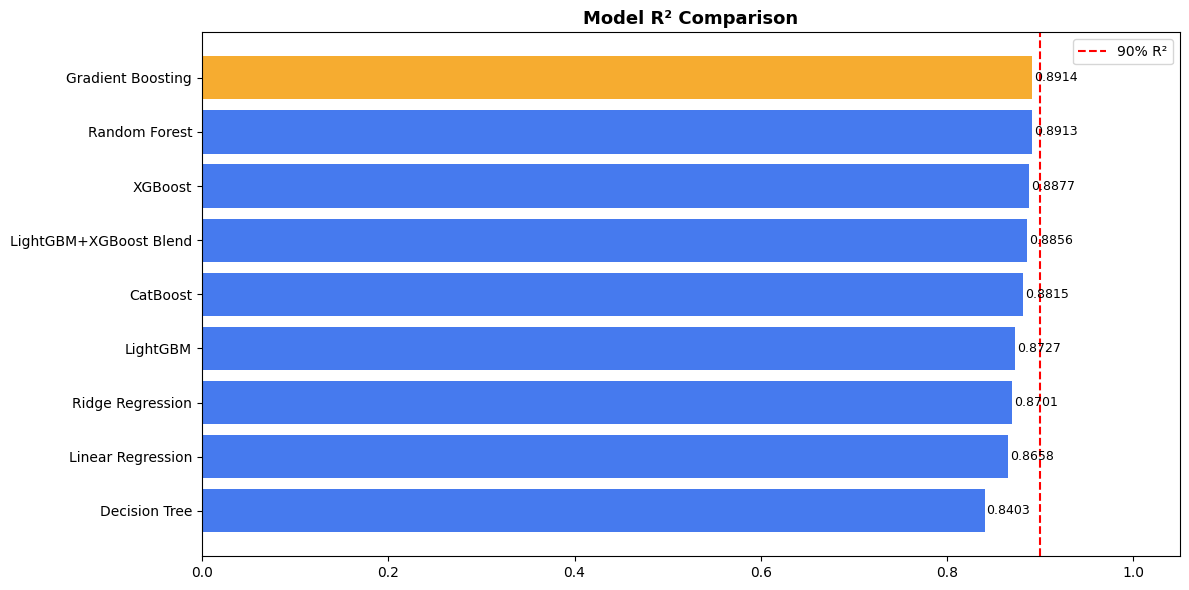

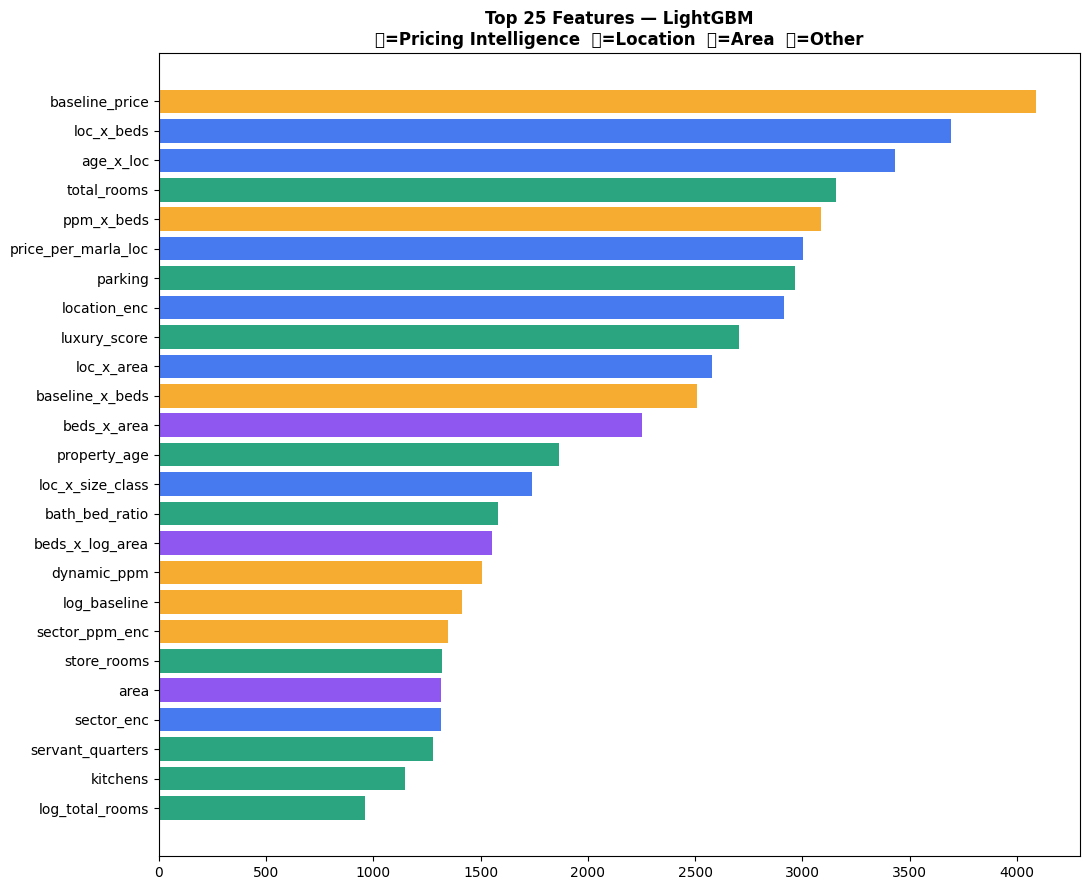

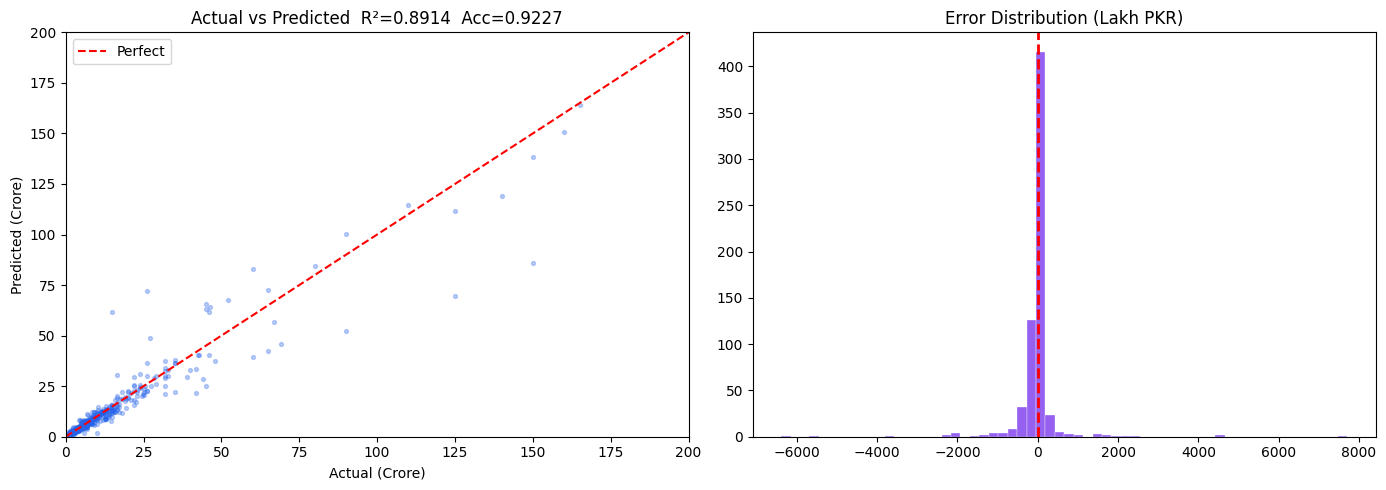

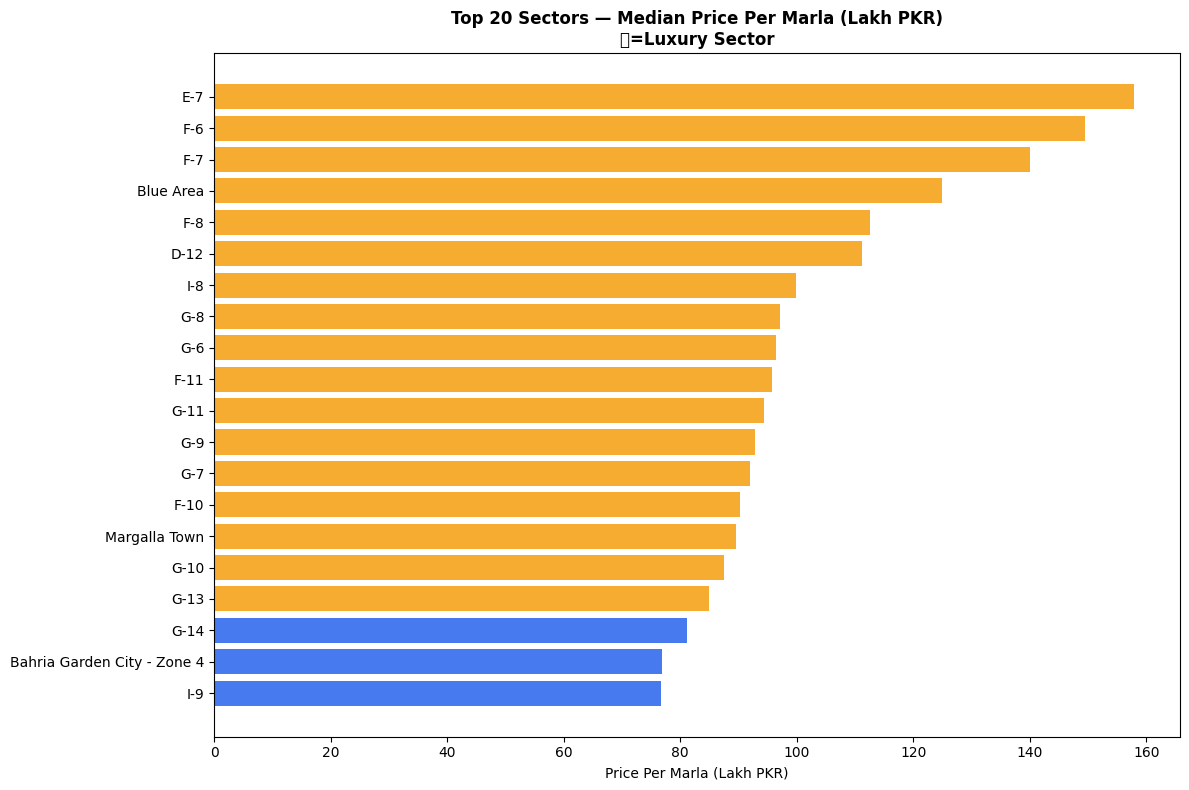

✅ All charts saved


In [51]:
# Model comparison
fig, ax = plt.subplots(figsize=(12,6))
r2s = dict(sorted({k:v['R2'] for k,v in results.items()}.items(), key=lambda x:x[1]))
cols = ['#f59e0b' if k==best_name else '#2563eb' for k in r2s]
bars = ax.barh(list(r2s.keys()), list(r2s.values()), color=cols, alpha=0.85)
ax.axvline(0.9, color='red', ls='--', lw=1.5, label='90% R²')
for bar,val in zip(bars,r2s.values()):
    ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)
ax.set_title('Model R² Comparison', fontsize=13, fontweight='bold')
ax.set_xlim(0,1.05); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR,'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# Feature importance from LightGBM
fi = pd.Series(lgbm.feature_importances_, index=feature_cols).sort_values(ascending=False).head(25)
fig,ax = plt.subplots(figsize=(11,9))
clrs = ['#f59e0b' if any(x in n for x in ['baseline','dynamic_ppm','ppm']) else
        '#2563eb' if 'loc' in n or 'sector' in n else
        '#7c3aed' if 'area' in n else '#059669' for n in fi.index]
ax.barh(fi.index[::-1], fi.values[::-1], color=clrs[::-1], alpha=0.85)
ax.set_title('Top 25 Features — LightGBM\n🟡=Pricing Intelligence  🔵=Location  🟣=Area  🟢=Other',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR,'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

# Actual vs predicted
fig,axes = plt.subplots(1,2,figsize=(14,5))
lim = min(max(y_test.max(),y_final.max())/1e7, 200)
axes[0].scatter(y_test/1e7, y_final/1e7, alpha=0.3, s=8, color='#2563eb')
axes[0].plot([0,lim],[0,lim],'r--',lw=1.5,label='Perfect')
axes[0].set_title(f'Actual vs Predicted  R²={results[best_name]["R2"]:.4f}  Acc={results[best_name]["Accuracy"]:.4f}')
axes[0].set_xlabel('Actual (Crore)'); axes[0].set_ylabel('Predicted (Crore)')
axes[0].set_xlim(0,lim); axes[0].set_ylim(0,lim); axes[0].legend()
errors = (y_final - y_test)/1e5
axes[1].hist(errors, bins=60, color='#7c3aed', alpha=0.8, edgecolor='white', lw=0.3)
axes[1].axvline(0, color='red', lw=2, ls='--')
axes[1].set_title('Error Distribution (Lakh PKR)')
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR,'actual_vs_predicted.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(CHARTS_DIR,'error_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

# Sector PPM chart
top_sec = sector_ppm_df.sort_values('median_ppm',ascending=False).head(20)
fig,ax = plt.subplots(figsize=(12,8))
clrs2 = ['#f59e0b' if s in luxury_sector_map else '#2563eb' for s in top_sec['sector']]
ax.barh(top_sec['sector'][::-1], top_sec['median_ppm'][::-1]/1e5, color=clrs2[::-1], alpha=0.85)
ax.set_title('Top 20 Sectors — Median Price Per Marla (Lakh PKR)\n🟡=Luxury Sector', fontsize=12, fontweight='bold')
ax.set_xlabel('Price Per Marla (Lakh PKR)')
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR,'sector_ppm.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ All charts saved')

In [52]:
print('\n' + '='*60)
print('  ✅  TRAINING COMPLETE')
print('='*60)
print(f'  Best Model : {best_name}')
print(f'  R² Score   : {results[best_name]["R2"]:.4f} ({results[best_name]["R2"]*100:.1f}%)')
print(f'  Accuracy   : {results[best_name]["Accuracy"]:.4f} ({results[best_name]["Accuracy"]*100:.1f}%)')
print(f'  MAE        : {results[best_name]["MAE"]/1e5:.1f} Lakh PKR')
print(f'  Features   : {len(feature_cols)}')
print(f'  Sectors    : {len(sector_ppm_map)}')
print(f'  Locations  : {len(loc_mean_map)}')
print('='*60)
print('\n  Pricing Intelligence:')
print(f'    sector_ppm.pkl            — {len(sector_ppm_map)} sector baseline PPMs')
print(f'    sector_area_ppm.pkl       — 118 × 5 area categories')
print(f'    sector_area_type_ppm.pkl  — 3-way: sector × area × property type')
print(f'    luxury_sector_map.pkl     — {len(luxury_sector_map)} luxury sector multipliers')
print(f'    area_multipliers.pkl      — global area-size scaling')
print(f'    premium_area_multipliers  — per-sector area scaling')
print(f'    pricing_intelligence.json — human-readable summary')
print('='*60)


  ✅  TRAINING COMPLETE
  Best Model : Gradient Boosting
  R² Score   : 0.8914 (89.1%)
  Accuracy   : 0.9227 (92.3%)
  MAE        : 208.0 Lakh PKR
  Features   : 144
  Sectors    : 105
  Locations  : 408

  Pricing Intelligence:
    sector_ppm.pkl            — 105 sector baseline PPMs
    sector_area_ppm.pkl       — 118 × 5 area categories
    sector_area_type_ppm.pkl  — 3-way: sector × area × property type
    luxury_sector_map.pkl     — 17 luxury sector multipliers
    area_multipliers.pkl      — global area-size scaling
    premium_area_multipliers  — per-sector area scaling
    pricing_intelligence.json — human-readable summary
